DYNAMIC PROGRAMMING: Value Iteration (BIS Error + deltaBIS)
✓ Found existing agent at artifacts\dp_bis_deltabis_agent.npz, will warm-start Value Iteration.

Computing Transition Matrix (P) and Rewards (R)...
✓ Transition matrix computed

Executing Value Iteration...
✓ Converged at iteration 0

Extracting optimal policy...

✓ Saved DP agent to artifacts\dp_bis_deltabis_agent.npz


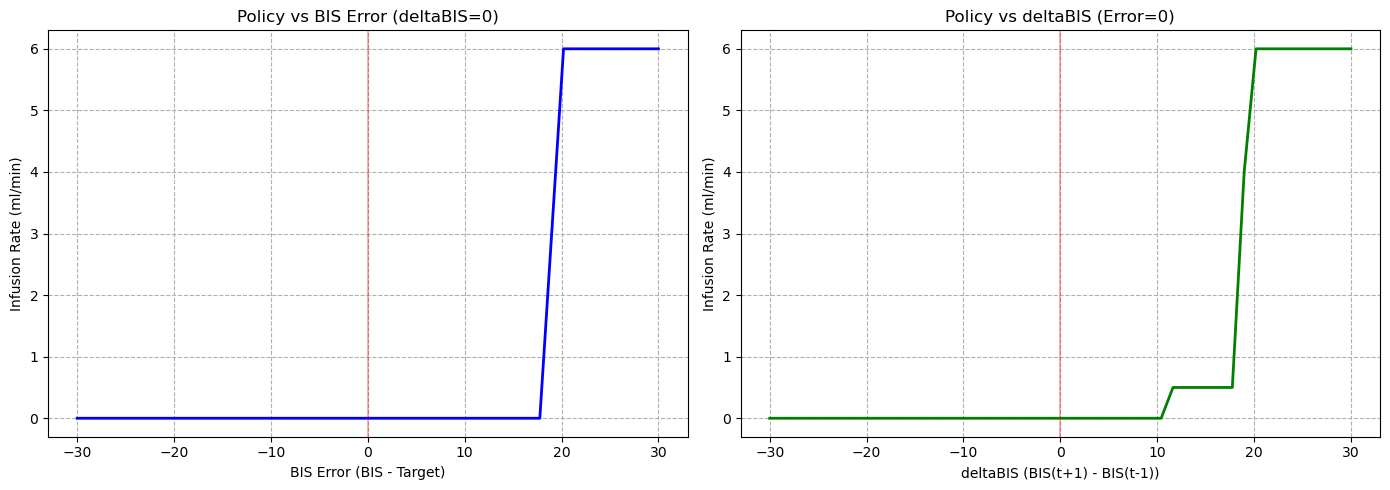


Evaluating policy for 10 episodes, each 720 steps...


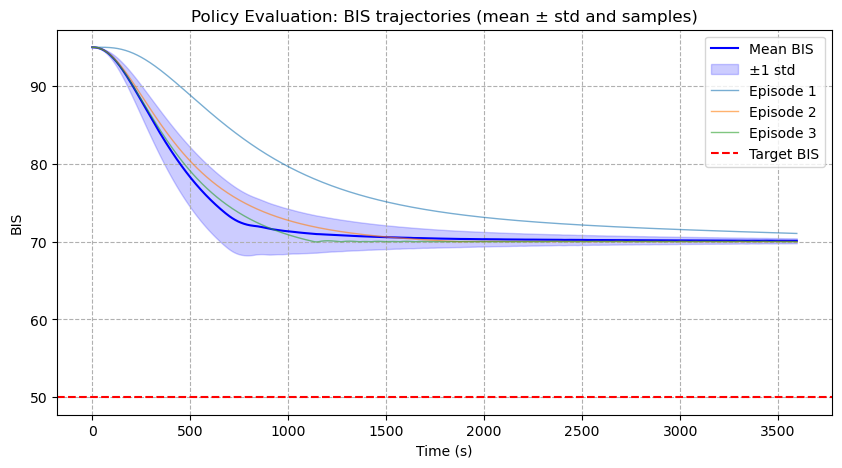

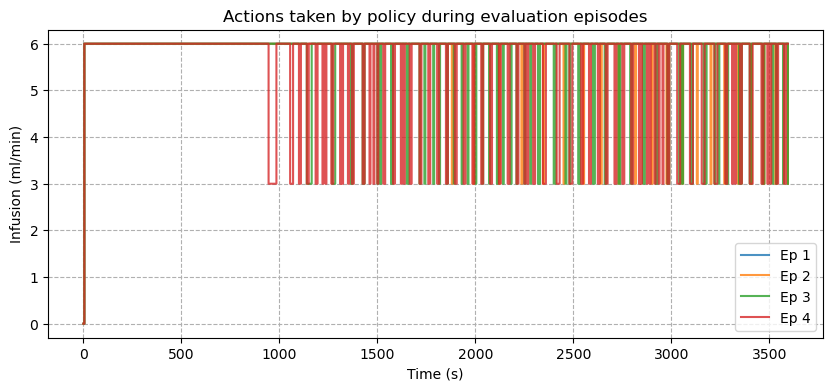

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

EPISODES = 100000
GAMMA = 0.69

# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================

V1, V2, V3 = 4.27, 18.9, 238.0
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
ke0 = 0.17
BIS_0, BIS_MAX, EC50, HILL = 95.0, 75.0, 3.5, 2.5
BIS_TARGET = 50.0

# ============================================================================
# RL CONFIGURATION
# ============================================================================

ACTIONS = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0]
BINS_PER_FEAT = 10
NUM_STATES = BINS_PER_FEAT**2  # 100 states

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [300, 600, 1200, 3600]
EVAL_TIME_STEP = 5 / 60
RANDOM_SEED = 42

AGE_GROUPS = {
    "25-29": (25, 29),
    "30-45": (30, 45),
    "46-60": (46, 60),
    "60-80": (60, 80),
    "80+": (80, 120),
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
DP_PATH = ARTIFACTS_DIR / "dp_bis_deltabis_agent.npz"

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def get_fuzzy_features(bis_error, deltabis):
    """Build fuzzy features from BIS error and deltaBIS."""
    error_scaled = np.clip(bis_error / 20.0, -1, 1)
    mu_error_neg = max(0, -error_scaled)
    mu_error_pos = max(0, error_scaled)

    delta_scaled = np.clip(deltabis / 20.0, -1, 1)
    mu_delta_neg = max(0, -delta_scaled)
    mu_delta_pos = max(0, delta_scaled)

    return np.array([mu_error_neg, mu_error_pos, mu_delta_neg, mu_delta_pos])


def state_to_idx(features):
    """Map fuzzy features to integer state index in [0, NUM_STATES-1]."""
    features = np.asarray(features)
    if features.shape != (4,):
        raise ValueError(f"features must be length-4 vector, got shape {features.shape}")

    error_feat = (features[1] - features[0]) * (BINS_PER_FEAT - 1)
    delta_feat = (features[3] - features[2]) * (BINS_PER_FEAT - 1)

    error_bin = int(np.clip(error_feat, 0, BINS_PER_FEAT - 1))
    delta_bin = int(np.clip(delta_feat, 0, BINS_PER_FEAT - 1))

    idx = error_bin * BINS_PER_FEAT + delta_bin
    return idx


def get_ce_from_error(bis_error):
    """Inverse PD relation to estimate Ce from BIS error."""
    bis = bis_error + BIS_TARGET
    ratio = (BIS_0 - bis) / BIS_MAX
    ratio = np.clip(ratio, 0.01, 0.99)
    ce = EC50 * (ratio / (1 - ratio)) ** (1 / HILL)
    return ce

# ============================================================================
# DP ALGORITHM: TRAINING SECTION
# ============================================================================

print("=" * 70)
print("DYNAMIC PROGRAMMING: Value Iteration (BIS Error + deltaBIS)")
print("=" * 70)

loaded_V = None
if DP_PATH.exists():
    try:
        data = np.load(DP_PATH)
        loaded_V = data["V"]
        print(f"✓ Found existing agent at {DP_PATH}, will warm-start Value Iteration.")
    except Exception as e:
        print(f"Could not load existing agent: {e}")

print("\nComputing Transition Matrix (P) and Rewards (R)...")
P = np.zeros((NUM_STATES, len(ACTIONS)), dtype=int)
R = np.zeros((NUM_STATES, len(ACTIONS)))

for s in range(NUM_STATES):
    error_bin = s // BINS_PER_FEAT
    delta_bin = s % BINS_PER_FEAT

    error_feat = (error_bin / (BINS_PER_FEAT - 1)) if BINS_PER_FEAT > 1 else 0.5
    delta_feat = (delta_bin / (BINS_PER_FEAT - 1)) if BINS_PER_FEAT > 1 else 0.5

    bis_error = (error_feat * 2 - 1) * 30
    deltabis = (delta_feat * 2 - 1) * 30

    for a_idx, infusion in enumerate(ACTIONS):
        bis_error_next = bis_error - (infusion / max(ACTIONS)) * 15
        deltabis_next = deltabis - (infusion / max(ACTIONS)) * 10

        bis_error_next = np.clip(bis_error_next, -30, 30)
        deltabis_next = np.clip(deltabis_next, -30, 30)

        features_next = get_fuzzy_features(bis_error_next, deltabis_next)
        s_next = state_to_idx(features_next)

        P[s, a_idx] = s_next
        R[s, a_idx] = -(abs(bis_error_next) + 0.5 * abs(deltabis_next))

print("✓ Transition matrix computed")

print("\nExecuting Value Iteration...")
if loaded_V is not None and loaded_V.shape == (NUM_STATES,):
    V = loaded_V.copy()
else:
    V = np.zeros(NUM_STATES)

for i in range(EPISODES):
    V_old = V.copy()
    Q_vals = R + GAMMA * V[P]
    V = np.max(Q_vals, axis=1)

    if np.max(np.abs(V - V_old)) < 1e-4:
        print(f"✓ Converged at iteration {i}")
        break

    if (i + 1) % 100 == 0:
        print(f"  Iteration {i+1}, max change: {np.max(np.abs(V - V_old)):.6f}")

print("\nExtracting optimal policy...")
Q_vals = R + GAMMA * V[P]
policy = np.argmax(Q_vals, axis=1).astype(int)

np.savez_compressed(
    DP_PATH,
    V=V,
    policy=policy,
    P=P,
    R=R,
    actions=np.array(ACTIONS, dtype=float),
    gamma=np.array([GAMMA], dtype=float),
)
print(f"\n✓ Saved DP agent to {DP_PATH}")

# ============================================================================
# VISUALIZATION: POLICY AND EVALUATION TRACES
# ============================================================================

np.random.seed(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

error_range = np.linspace(-30, 30, 50)
deltabis_fixed = 0.0
chosen_doses_error = []
for err in error_range:
    features = get_fuzzy_features(err, deltabis_fixed)
    s = state_to_idx(features)
    chosen_doses_error.append(ACTIONS[policy[s]])

axes[0].plot(error_range, chosen_doses_error, color="blue", lw=2)
axes[0].set_title("Policy vs BIS Error (deltaBIS=0)")
axes[0].set_xlabel("BIS Error (BIS - Target)")
axes[0].set_ylabel("Infusion Rate (ml/min)")
axes[0].grid(True, linestyle="--")
axes[0].axvline(0, color="red", linestyle="-", alpha=0.3, label="Target")

deltabis_range = np.linspace(-30, 30, 50)
error_fixed = 0.0
chosen_doses_delta = []
for db in deltabis_range:
    features = get_fuzzy_features(error_fixed, db)
    s = state_to_idx(features)
    chosen_doses_delta.append(ACTIONS[policy[s]])

axes[1].plot(deltabis_range, chosen_doses_delta, color="green", lw=2)
axes[1].set_title("Policy vs deltaBIS (Error=0)")
axes[1].set_xlabel("deltaBIS (BIS(t+1) - BIS(t-1))")
axes[1].set_ylabel("Infusion Rate (ml/min)")
axes[1].grid(True, linestyle="--")
axes[1].axvline(0, color="red", linestyle="-", alpha=0.3, label="Target")

plt.tight_layout()
plt.show()

# EVALUATION ON POPULATION DATASET

In [ ]:
import pandas as pd
import random

from utils.eval_metrics import (
    calculate_bis_metrics,
    get_age_group,
    create_results_dataframe,
    create_summary_by_age_group,
    save_evaluation_results,
)

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

def load_data(path):
    return pd.read_csv(path)


def preprocess_data(df):
    df = df.copy()

    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == "older" else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50

    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df


def schnider_model(age, weight, height, sex):
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight**2) / (height**2)
    else:
        lbm = 1.07 * weight - 148 * (weight**2) / (height**2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)
    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array(
        [
            [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
            [k12_s, -k21_s, 0, 0],
            [k13_s, 0, -k31_s, 0],
            [ke0_s, 0, 0, -ke0_s],
        ],
        dtype=float,
    )
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    return {"A": A, "B": B}


def generate_schnider_dataset(df):
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"],
        )
        params_list.append(params)

    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)


# ============================================================================
# EVALUATOR CLASS
# ============================================================================

class DPEvaluator:
    def __init__(self, policy, actions):
        self.policy = policy
        self.actions = actions
        self.target = BIS_TARGET
        self.bis0 = BIS_0
        self.bis_max = BIS_MAX
        self.ec50 = EC50
        self.hill = HILL
        self.bins_per_feat = BINS_PER_FEAT

    def _get_state_idx(self, bis_error, deltabis):
        error_scaled = np.clip(bis_error / 20.0, -1, 1)
        mu_error_neg = max(0, -error_scaled)
        mu_error_pos = max(0, error_scaled)

        delta_scaled = np.clip(deltabis / 20.0, -1, 1)
        mu_delta_neg = max(0, -delta_scaled)
        mu_delta_pos = max(0, delta_scaled)

        features = np.array([mu_error_neg, mu_error_pos, mu_delta_neg, mu_delta_pos])

        error_feat = (features[1] - features[0]) * (self.bins_per_feat - 1)
        delta_feat = (features[3] - features[2]) * (self.bins_per_feat - 1)

        error_bin = int(np.clip(error_feat, 0, self.bins_per_feat - 1))
        delta_bin = int(np.clip(delta_feat, 0, self.bins_per_feat - 1))

        idx = error_bin * self.bins_per_feat + delta_bin
        return min(idx, len(self.policy) - 1)

    def simulate(self, patient_row, duration_seconds):
        duration_steps = int(duration_seconds / 5)

        A = np.asarray(patient_row["A"], dtype=float)
        B = np.asarray(patient_row["B"], dtype=float)
        x = np.zeros((4, 1), dtype=float)

        bis_log = []
        bis_prev_prev = self.bis0
        bis_prev = self.bis0

        for t in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)

            ce_h = np.power(ce, self.hill)
            ec50_h = np.power(self.ec50, self.hill)
            if ce_h + ec50_h > 0:
                bis_ideal = self.bis0 - self.bis_max * (ce_h / (ce_h + ec50_h))
            else:
                bis_ideal = self.bis0

            bis_ideal = np.clip(float(bis_ideal), 0, 100)
            measured_bis = np.clip(bis_ideal + np.random.normal(0, 3), 0, 100)

            bis_error = measured_bis - self.target
            deltabis = measured_bis - bis_prev_prev if t > 0 else 0.0
            s_idx = self._get_state_idx(bis_error, deltabis)

            a_idx = int(self.policy[s_idx])
            u = float(self.actions[a_idx])

            x_dot = A @ x + B * u
            x = x + x_dot * EVAL_TIME_STEP
            x = np.clip(x, -10.0, 10.0)

            bis_prev_prev = bis_prev
            bis_prev = measured_bis
            bis_log.append(float(measured_bis))

        return np.array(bis_log)


# ============================================================================
# EVALUATION EXECUTION
# ============================================================================

print("\n" + "=" * 70)
print("EVALUATION ON POPULATION DATASET")
print("=" * 70)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"\n1. Loading patient data from {DATA_PATH}...")
df = load_data(DATA_PATH)
df = preprocess_data(df)
print(f"   Loaded {len(df)} patients")

print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
print(f"   Sampled {len(sample_df)} patients")

print("\n3. Generating Schnider PK/PD parameters...")
eval_df = generate_schnider_dataset(sample_df)
print(f"   Generated parameters for {len(eval_df)} patients")

print(f"\n4. Loading trained DP agent from {DP_PATH}...")
dp_data = np.load(DP_PATH)
policy_eval = dp_data["policy"]
actions_eval = dp_data["actions"]
print(f"   Loaded policy: shape {policy_eval.shape}")

evaluator = DPEvaluator(policy_eval, actions_eval)

print(f"\n5. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
patient_results = []

for idx, (_, patient) in enumerate(eval_df.iterrows()):
    if (idx + 1) % 50 == 0:
        print(f"   Processing patient {idx + 1}/{len(eval_df)}...")

    patient_id = patient["PatientID"]
    age = patient["AgeCategory"]
    age_group = get_age_group(age, AGE_GROUPS)

    results = {}
    for ep_len in EVAL_EPISODE_LENGTHS:
        bis_traj = evaluator.simulate(patient, ep_len)
        metrics = calculate_bis_metrics(bis_traj, BIS_TARGET)
        results[ep_len] = metrics

    patient_results.append(
        {
            "patient_id": patient_id,
            "age": age,
            "age_group": age_group,
            "results": results,
        }
    )

results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

print("\n6. Saving evaluation results...")
save_evaluation_results(
    results_df,
    summary_df,
    "dp_bis_deltabis_agent",
    str(METRICS_DIR),
)

print("\n" + "=" * 70)
print("Evaluation complete!")
print(f"  - Results: {len(results_df)} patients")
print(f"  - Age groups: {results_df['AgeGroup'].nunique()}")
print(f"  - Episode lengths: {len(EVAL_EPISODE_LENGTHS)}")
print("=" * 70)

Loading Population Data...

Sampling 50 patients from 237630 total...
Generating Schnider parameters for 50 patients...
Loading DP Agent...
Evaluating on Population...


C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:123: RuntimeWarning: overflow encountered in scalar power
  ce_h = ce ** self.hill
C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:125: RuntimeWarning: invalid value encountered in scalar divide
  bis_ideal = self.bis0 - self.bis_max * (ce_h / (ce_h + ec50_h))
C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:143: RuntimeWarning: overflow encountered in matmul
  x_dot = A @ x + B * u
C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:144: RuntimeWarning: invalid value encountered in add
  x = x + x_dot * dt
C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:143: RuntimeWarning: invalid value encountered in matmul
  x_dot = A @ x + B * u



--- Evaluation Results Summary ---
            MDPE      MDAPE     Wobble  Controlled (%)
count  50.000000  50.000000  50.000000            50.0
mean   89.869011  89.869011   4.104531             0.0
std     0.169899   0.169899   0.108789             0.0
min    89.475424  89.475424   3.869676             0.0
25%    89.756506  89.756506   4.036837             0.0
50%    89.851638  89.851638   4.122618             0.0
75%    89.981525  89.981525   4.169763             0.0
max    90.300446  90.300446   4.322812             0.0

Best Patient: {'PatientID': 149460.0, 'MDPE': 89.47542354221613, 'MDAPE': 89.47542354221613, 'Wobble': 4.105434109571561, 'Controlled (%)': 0.0}


# LOAD AND EVALUATE SAVED DP AGENT

In [12]:
from utils.eval_runner import run_saved_dp_evaluation

results_df = run_saved_dp_evaluation(
    dp_path=DP_PATH,
    evaluator_cls=DPEvaluator,
    load_data_fn=load_data,
    preprocess_data_fn=preprocess_data,
    generate_dataset_fn=generate_schnider_dataset,
    sample_size=100,
)


LOADING SAVED DP AGENT

Loading agent from: artifacts\dp_bis_deltabis_agent.npz
  - Loaded V (value function): shape (100,)
  - Loaded policy: shape (100,)
  - Loaded P (transitions): shape (100, 7)
  - Loaded R (rewards): shape (100, 7)
  - Actions available: [0.  0.5 1.  2.  3.  4.  6. ]
  - Gamma (discount): [0.69]

EVALUATING ON POPULATION SAMPLE

Sampling 100 patients from 237630 total...
Generating Schnider parameters for 100 patients...

Running evaluation simulation (120 min per patient)...


C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:123: RuntimeWarning: overflow encountered in scalar power
  ce_h = ce ** self.hill
C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:125: RuntimeWarning: invalid value encountered in scalar divide
  bis_ideal = self.bis0 - self.bis_max * (ce_h / (ce_h + ec50_h))
C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:143: RuntimeWarning: overflow encountered in matmul
  x_dot = A @ x + B * u
C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:144: RuntimeWarning: invalid value encountered in add
  x = x + x_dot * dt
C:\Users\hsoukrat\AppData\Local\Temp\ipykernel_16240\461079348.py:143: RuntimeWarning: invalid value encountered in matmul
  x_dot = A @ x + B * u



EVALUATION RESULTS

Evaluated 100 patients successfully

             MDPE       MDAPE      Wobble  Controlled (%)
count  100.000000  100.000000  100.000000           100.0
mean    89.913053   89.913053    4.120975             0.0
std      0.189597    0.189597    0.102742             0.0
min     89.504580   89.504580    3.814747             0.0
25%     89.790571   89.790571    4.058579             0.0
50%     89.869927   89.869927    4.113019             0.0
75%     90.033578   90.033578    4.196855             0.0
max     90.411126   90.411126    4.407638             0.0

--- Best Controlled Patient (ID: 233751) ---
  MDPE: 89.50%
  MDAPE: 89.50%
  Wobble: 3.91%
  Controlled (%): 0.00%

--- Worst Controlled Patient (ID: 114726) ---
  MDPE: 90.41%
  MDAPE: 90.41%
  Wobble: 4.01%
  Controlled (%): 0.00%
